## Функции. Рекурсия.


### Упражение 1
Написать функцию, считающую N-ое число Фибоначчи (N вводится с клавиатуры).


In [ ]:
def fib(n):
    if n == 0:
        return 0
    if n == 1:
        return 1
    return fib(n - 1) + fib(n - 2)


N = int(input())
print(fib(N))


3



### Упражение 2
Написать функцию, раскладывающую число на простые множители (число вводится с клавиатуры).


In [11]:
def multipliers(number):
    multiple = []
    buffer = number

    while (buffer > 1):
        for i in range(2, buffer + 1):
            multiple_i = []

            if number % i == 0:
                for f in range(1, i + 1):
                    if i % f == 0:
                        multiple_i.append(f)

                if multiple_i == [1, i]:
                    multiple.append(i)

                buffer = int(buffer // i)

    return multiple


N = int(input())
print(multipliers(N))


KeyboardInterrupt: 



### Упражнение 3
Со времен Евклида известно, что для любых положительных a и b существуют такие целые x и y, что ax + by = d, где d – наибольший общий делитель a и b. По заданным a и b найти x, y, d.

Вход. Каждая строка содержит два натуральных числа a и b, разделенных пробелом.

Выход. Для каждой пары a и b в отдельной строке вывести три целых числа x, y и d, разделенных пробелом. Если искомых значений x и y несколько, то следует выводить такую пару, для которой |x| + |y| минимально. Если и таких пар несколько, то вывести ту пару, в которой x минимально.

|Пример входа|Пример выхода|
|-|-|
|4 6|-1 1 2|
|17 17|0 1 17|
|5 3|-1 2 1|


In [ ]:
def dividers(a, b):
    if b == 0:
        return 1, 0, a
    x, y, d = dividers(b, a % b)
    return y, x - (a // b) * y, d


a, b = map(int, input().split())

x, y, d = dividers(a, b)

print(x, y, d)


-1 1 2






### Упражнение 4
Напишите функцию для вывода треугольника. Функция принимает два аргумента – size (количество строк, на которых будет строиться треугольник) и symb (символ, используемый для заполнения треугольника).

Пример входа: `7 c`

Пример выхода:
![image-2.png](attachment:image-2.png)



 

In [ ]:
size_symb = list(input().split())
size = int(size_symb.pop(0))
symbol = str(size_symb.pop(0))
for i in range(1, ((size + 1) // 2) + 1):
    print(i * symbol)
for i in range(size // 2, 0, -1):
    print(i * symbol)


c
cc
ccc
cccc
ccc
cc
c


## Библиотеки. Numpy

Для решения практических задач часто бывает необходимо 
Для вычисления математических функций в python есть стандартная библиотека [math](http://docs.scipy.org/doc/numpy/reference/generated/numpy.log.html#numpy.log). Однако значительно более сильным инструментом является библиотека [numpy](http://docs.scipy.org/doc/numpy/reference/generated/numpy.polyfit.html).
Данная библиотека обеспечивает удобную работу с векторами, которые здесь наззываются массивами (arrays).

Т.е., если у нас есть массив X и мы вызовем numpy.log(x), то логарифм будет взят от каждого элемента и возвращен будет массив значений логарифмов элементов.

Традиционно библиотека numpy (как и любая другая) подключается командой:

``` python
import numpy
```
Пример вызова функции из библиотеки
``` python
numpy.cos(x)
```
Библиотеки можно подключить под псевдонимом:
``` python
import numpy as np
```
В таком случае мы можем вызывать функции так:
``` python
np.cos(x)
```
Такой код значительно проще читать и писать.

Возможно также подключать отдельные функции из библиотеки, это позволит вызывать их без указания названия библиотеки:
``` python
from numpy import cos
cos(x)
```
``` python
from numpy import cos
cos(x)
```

Как уже было сказано, основной объект, с которым принято взаимодействовать в numpy -- массивы. Они отличаются от списков тем, что могут хранить значения, имеющие один и тот же тип, и имеют определенные по-другому операции. Например:

``` python
a = np.array([1,2,3])
b = np.array([1,2,3])
c = a + b
```
Если бы `a` и `b` были списками, то мы получили бы "сшитый" список. Однако в данном случае мы получим результат поэлементного сложения двух массивов.

### *Broadcasting

Одной из фишек библиотеки numpy является [бродкастинг](https://numpy.org/doc/stable/user/basics.broadcasting.html). Он позволяет существенно упростить многие операции с массивами и матрицами. Самый простой пример бродкастинга:
```python
a = np.array([1,2,3,4])
b = 1
c = a + b
```
Казалось бы, мы должны получить ошибку, ведь массив и число -- разные типы данных. Однако в данном случае numpy поймет, что вы хотите прибавить единицу ко всем элементам массива и сделает это. Аналогично можно прибавлять к матрице вектор или строку соответствующего размера.

### Упражнение 5

Создайте матрицу размером `NxM`, заполненную "спиралью":

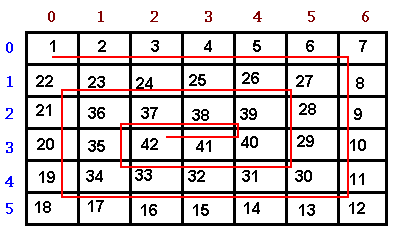

Умножьте каждую строку получившейся матрицы на номер строки, выведите результат.


In [ ]:
import numpy as np


n, m = map(int, input().split())

a = np.zeros((n, m), dtype=int)

num = 1
top = 0
bottom = n - 1
left = 0
right = m - 1

while top <= bottom and left <= right:

    for j in range(left, right + 1):
        a[top, j] = num
        num += 1
    top += 1

    for i in range(top, bottom + 1):
        a[i, right] = num
        num += 1
    right -= 1

    if top <= bottom:
        for j in range(right, left - 1, -1):
            a[bottom, j] = num
            num += 1
        bottom -= 1

    if left <= right:
        for i in range(bottom, top - 1, -1):
            a[i, left] = num
            num += 1
        left += 1

for i in range(n):
    a[i] *= i

print(a)


[[ 1  2  3  4  5  6  7  8]
 [26 27 28 29 30 31 32  9]
 [25 44 45 46 47 48 33 10]
 [24 43 54 55 56 49 34 11]
 [23 42 53 52 51 50 35 12]
 [22 41 40 39 38 37 36 13]
 [21 20 19 18 17 16 15 14]]




### Упражнение 6

Напишите функцию, считающую коэффициенты МНК для набора измерений `x` и `y`.


In [ ]:
import numpy as np


def mnk(x, y): # На вход функции подаются два списка - x и у. В лабораторной работе 1.1.4 это I и U
    x = np.array(x)
    y = np.array(y)

    a = ((np.mean(x * y) - np.mean(x) * np.mean(y)) /
         (np.mean(x ** 2) - np.mean(x) ** 2))

    b = np.mean(y) - a * np.mean(x)

    return a, b



### Упражнение 7

Напишите функцию, решающую линейную систему уравнений, заданную расширенной матрицей. На вход подаются `N` и `M` -- количество строк и столбцов расширенной матрицы, далее вводятся `N` строк, каждая из которых содержит `M` чисел.


In [ ]:
import numpy as np


def solve(a):
    a = np.array(a, dtype=float)

    n, m = a.shape
    variables = m - 1

    for i in range(min(n, variables)):
        k = i

        while k < n and a[k, i] == 0:
            k += 1

        if k == n:
            continue

        a[[i, k]] = a[[k, i]]

        a[i] = a[i] / a[i, i]

        for j in range(n):
            if j != i:
                a[j] = a[j] - a[j, i] * a[i]

    return a[:, -1]


n, m = map(int, input().split())

a = []

for i in range(n):
    a.append(list(map(float, input().split())))

print(solve(a))


[3. 4. 3.]



### Упражнение 8* (для осн и продв)

Реализуйте функцию, генерирующую набор данных размером `N`, которые методом МНК аппроксимируются прямой с коэффициентами `a` и `b`. Для этого вам пригодится библиотека `random` и функция `random.gauss()`.





## *Функция eval()

В Python есть встроенная функция `eval()`, которая выполняет строку с
кодом и возвращает результат выполнения:

``` python
>>> eval("2 + 3*len('banana')")
20
```

Это очень мощная, но и довольно небезопасная команда.
Например, если строкой, которую мы передадим в `eval()`, окажется
`"os.system('rm -rf /')"` (в терминале Linux), то интерпретатор начнет удалять все файлы, включая системные, с компьютера.

## *Задачи по numpy для дополнительного изучения
https://github.com/rougier/numpy-100